In [2]:
import sys 
sys.path.append("../../src")
import kibble_zurek as kz

from common_imports import *

In [82]:
import numpy as np
from tqdm import tqdm

def compute_Pn_vs_time(L, taus, n_values):
    """
    Returns numpy array of shape (len(taus), len(n_values), len(t), 2)
    with columns [t, P_n - 2^(-n)] for each tau and n.
    """
    all_data = []

    for tau in tqdm(taus, desc="taus"):
        t = np.linspace(-1/4* tau, 1/4*tau, 50)
        states = [kz.state(L, tau, ti) for ti in t]  # heavy step

        tau_data = []
        for n in n_values:
            P_vals = np.array([kz.P_n(n, s) - 2 ** (-n) for s in states])
            tau_data.append(np.column_stack((t, P_vals)))
        all_data.append(tau_data)

    return np.array(all_data, dtype=float)


In [89]:
taus = [1, 10, 100,1000]
n_values = [2, 4, 8,12]

data = compute_Pn_vs_time(100, taus, n_values)

taus: 100%|██████████| 4/4 [02:02<00:00, 30.73s/it]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_22462/4112486852.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.array(all_data, dtype=float)


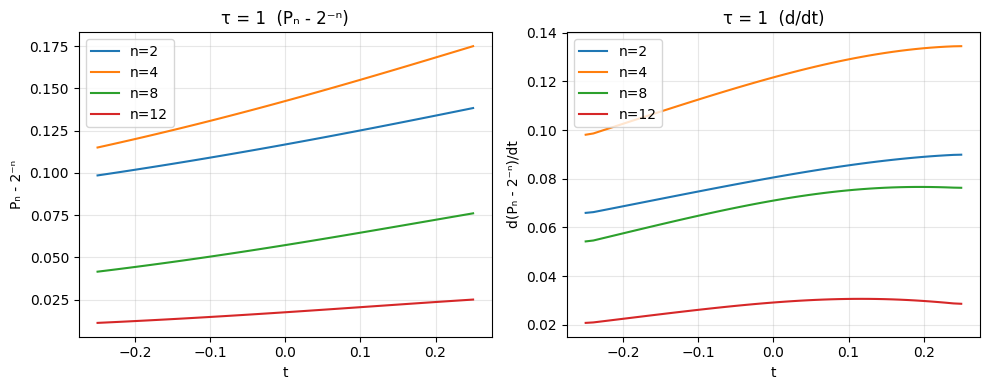

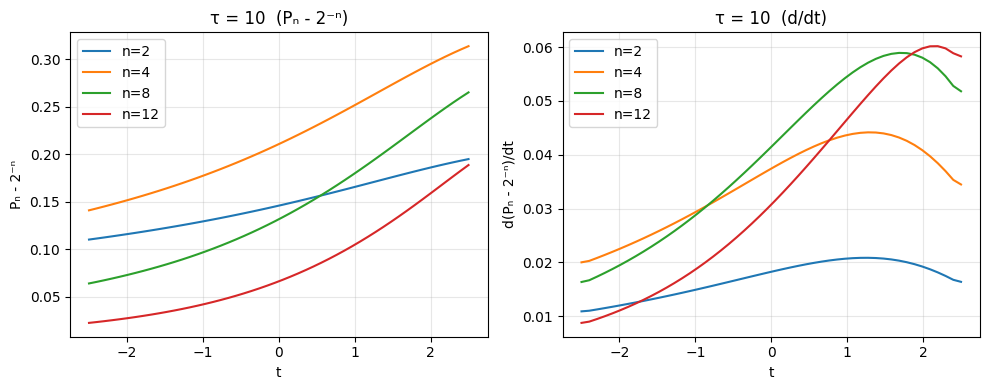

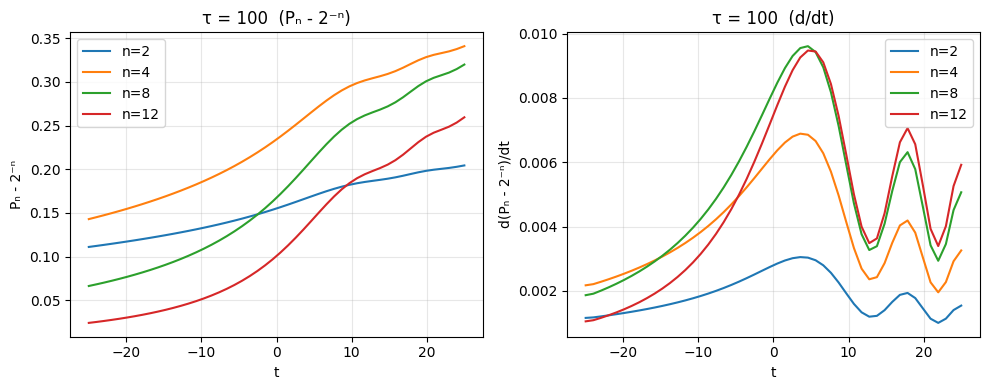

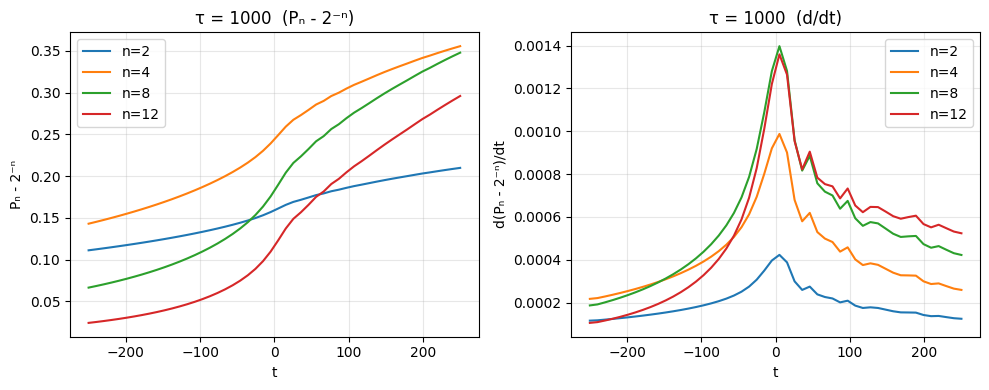

In [90]:

for i, tau in enumerate(taus):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    
    for j, n in enumerate(n_values):
        t = data[i, j, :, 0]
        P = data[i, j, :, 1]
        dPdt = np.gradient(P, t)

        axes[0].plot(t, P, label=f"n={n}")
        axes[1].plot(t, dPdt, label=f"n={n}")

    axes[0].set_title(f"τ = {tau}  (Pₙ - 2⁻ⁿ)")
    axes[1].set_title(f"τ = {tau}  (d/dt)")
    axes[0].set_xlabel("t")
    axes[1].set_xlabel("t")
    axes[0].set_ylabel("Pₙ - 2⁻ⁿ")
    axes[1].set_ylabel("d(Pₙ - 2⁻ⁿ)/dt")

    for ax in axes:
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


array([[[[-2.00000000e+00,  1.47003431e-02],
         [-1.91666667e+00,  1.51371625e-02],
         [-1.83333333e+00,  1.60497711e-02],
         [-1.75000000e+00,  1.70447946e-02],
         [-1.66666667e+00,  1.81317644e-02],
         [-1.58333333e+00,  1.93214419e-02],
         [-1.50000000e+00,  2.06259582e-02],
         [-1.41666667e+00,  2.20589515e-02],
         [-1.33333333e+00,  2.36356924e-02],
         [-1.25000000e+00,  2.53731784e-02],
         [-1.16666667e+00,  2.72901718e-02],
         [-1.08333333e+00,  2.94071420e-02],
         [-1.00000000e+00,  3.17460552e-02],
         [-9.16666667e-01,  3.43299341e-02],
         [-8.33333333e-01,  3.71820794e-02],
         [-7.50000000e-01,  4.03248115e-02],
         [-6.66666667e-01,  4.37775492e-02],
         [-5.83333333e-01,  4.75540025e-02],
         [-5.00000000e-01,  5.16582192e-02],
         [-4.16666667e-01,  5.60792114e-02],
         [-3.33333333e-01,  6.07839165e-02],
         [-2.50000000e-01,  6.57083536e-02],
         [

In [57]:
np.shape(derivs)

()

In [59]:
data

{1: {2: {'t': array([-2.        , -1.91666667, -1.83333333, -1.75      , -1.66666667,
          -1.58333333, -1.5       , -1.41666667, -1.33333333, -1.25      ,
          -1.16666667, -1.08333333, -1.        , -0.91666667, -0.83333333,
          -0.75      , -0.66666667, -0.58333333, -0.5       , -0.41666667,
          -0.33333333, -0.25      , -0.16666667, -0.08333333,  0.        ]),
   'P_n': array([0.29214701+0.j, 0.29337204+0.j, 0.29466987+0.j, 0.296047  +0.j,
          0.29751067+0.j, 0.29906896+0.j, 0.30073091+0.j, 0.30250662+0.j,
          0.3044074 +0.j, 0.3064459 +0.j, 0.30863626+0.j, 0.31099426+0.j,
          0.31353745+0.j, 0.31628527+0.j, 0.31925911+0.j, 0.32248229+0.j,
          0.32597991+0.j, 0.32977855+0.j, 0.33390558+0.j, 0.33838825+0.j,
          0.34325211+0.j, 0.3485189 +0.j, 0.35420351+0.j, 0.36031008+0.j,
          0.36682707+0.j])},
  4: {'t': array([-2.        , -1.91666667, -1.83333333, -1.75      , -1.66666667,
          -1.58333333, -1.5       , -1.41666667, 